# Subreddit relations investigation

Subreddit-subreddit relations are created based on the amount of shared users they have. However, creating a relation based on a single shared user is not statically relevant. This notebook aims to measure the relations and the network created by them and find the ideal methods of selecting what is the best method to find relevant relations between subreddits.

In [1]:
import duckdb
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

con = duckdb.connect()

In [2]:
relations_df = con.execute("""
    SELECT * FROM '../storage/relations/2024-12/raw_relations.parquet'
""").df()

relations_df.head()

,subreddit_id_a,subreddit_id_b,shared_users,users_a,users_b,jaccard,cosine
0,t5_1uyb31,t5_2qhmc,1,1294,903,0.000455,0.000925
1,t5_2rbuf,t5_2rpmh,1,764,1175,0.000516,0.001055
2,t5_2qiq9,t5_2r6jm,1,553,591,0.000875,0.001749
3,t5_2rxqu,t5_2sfad,1,1363,346,0.000585,0.001456
4,t5_2rfxq,t5_2rpqd,1,253,294,0.001832,0.003667


In [3]:
G = nx.from_pandas_edgelist(
    relations_df,
    source="subreddit_id_a",
    target="subreddit_id_b",
    edge_attr=["shared_users", "jaccard", "cosine"]
)

print(f"Nodes: {G.number_of_nodes():_}")
print(f"Edges: {G.number_of_edges():_}")
print(f"Density: {nx.density(G):.6f}")

Nodes: 16_499
Edges: 4_430_772
Density: 0.032555


Shared users max value (p100): 16_012


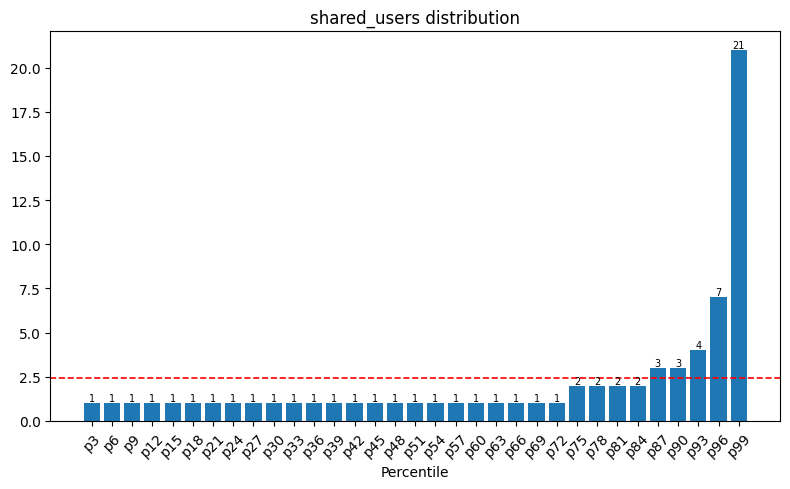

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
col = "shared_users"

percentiles = list(range(3, 100, 3))
values = np.percentile(relations_df[col], percentiles)
max_value = np.max(relations_df[col])
avg = np.mean(relations_df[col])
    
plt.bar([f"p{p}" for p in percentiles], values, edgecolor="none")
plt.axhline(avg, color="red", linestyle="--", linewidth=1.2, label=f"Mean: {avg:.1f}")
plt.title(f"{col} distribution")
plt.xlabel("Percentile")
plt.tick_params(axis="x", rotation=45)
for i, (bar, val) in enumerate(zip(ax.patches, values)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f"{int(val)}", ha="center", va="bottom", fontsize=7)

print(f"Shared users max value (p100): {max_value:_}")

plt.tight_layout()
plt.savefig(fname="images/shared_user_sidt.png")
plt.show()

In [5]:
raw_node_stats = con.execute("""
    WITH edges AS (
        SELECT subreddit_id_a AS subreddit_id, shared_users FROM relations_df
        UNION ALL
        SELECT subreddit_id_b, shared_users FROM relations_df
    )
    SELECT
        subreddit_id,
        COUNT(*) AS degree,
        SUM(shared_users) AS strength,
        AVG(shared_users) AS avg_edge_weight,
        STDDEV(shared_users) / AVG(shared_users) AS weight_cv
    FROM edges
    GROUP BY 1
""").df()

In [6]:
def relations_threshold_analysis(threshold):
    filtered_relations_df = relations_df[relations_df["shared_users"] >= threshold]
    filtered_size = len(filtered_relations_df)
    percentage = 100 * filtered_size / len(relations_df)
    print(f"Relations with at least {threshold} shared users: {filtered_size:_}, (~{percentage:.2f}%)")

for i in (2, 5, 10, 20, 50, 100):
    relations_threshold_analysis(i)

Relations with at least 2 shared users: 1_184_758, (~26.74%)
Relations with at least 5 shared users: 285_965, (~6.45%)
Relations with at least 10 shared users: 114_922, (~2.59%)
Relations with at least 20 shared users: 48_875, (~1.10%)
Relations with at least 50 shared users: 16_111, (~0.36%)
Relations with at least 100 shared users: 6_481, (~0.15%)


We can notice that the network generated with no criteria relations (single shared user included) is very dense (`density=~3%`). And that only 26% of the relations have more then 1 shared users, and less then 2.6% of the relations have at least 10 shared users. 

To reduce noise and remove concident shared users that doesn't represent a correlation between the 2 subreddits, we are going to apply an initial filter of at least 10 shared users. However, this by itself doesn't remove all noise, a relation of 10 shared user between 2 subreddits with more then 1k users each doesn't represent a relevant relation. For this reason, we are going to apply a backbone extraction strategy to keep only the structurally and statistically meaningful relations:

In [7]:
threshold = 10
filtered_df = relations_df[relations_df["shared_users"] >= threshold]

In [8]:
filtered_G = nx.from_pandas_edgelist(
    filtered_df,
    source="subreddit_id_a",
    target="subreddit_id_b",
    edge_attr=["shared_users", "jaccard", "cosine"]
)

print(f"Nodes: {filtered_G.number_of_nodes():_}")
print(f"Edges: {filtered_G.number_of_edges():_}")
print(f"Density: {nx.density(filtered_G):.6f}")

print(f"Excluded nodes from filter (isolated nodes): {(G.number_of_nodes() - filtered_G.number_of_nodes()):_}")

Nodes: 14_354
Edges: 114_922
Density: 0.001116
Excluded nodes from filter (isolated nodes): 2_145


In [9]:
node_stats = con.execute("""
    WITH edges AS (
        SELECT subreddit_id_a AS subreddit_id, shared_users FROM filtered_df
        UNION ALL
        SELECT subreddit_id_b, shared_users FROM filtered_df
    )
    SELECT
        subreddit_id,
        COUNT(*) AS degree,
        SUM(shared_users) AS strength,
        AVG(shared_users) AS avg_edge_weight,
        STDDEV(shared_users) / AVG(shared_users) AS weight_cv
    FROM edges
    GROUP BY 1
""").df()

print(node_stats[["degree", "strength", "avg_edge_weight", "weight_cv"]].describe(
    percentiles=[.25, .50, .75, .90, .99]
))

             degree       strength  avg_edge_weight     weight_cv
count  14354.000000   14354.000000     14354.000000  12436.000000
mean      16.012540     576.454229        30.855646      0.817759
std       57.243216    2646.165204        26.433009      0.562517
min        1.000000      10.000000        10.000000      0.000000
25%        2.000000      53.000000        17.285714      0.438856
50%        5.000000     146.000000        24.250000      0.715844
75%       13.000000     400.000000        35.949342      1.068751
90%       32.000000    1132.000000        53.000000      1.499135
99%      179.000000    7154.460000       124.144615      2.660584
max     4197.000000  209333.000000       754.000000     10.464128


Max weight (p100): 10.464128366508264


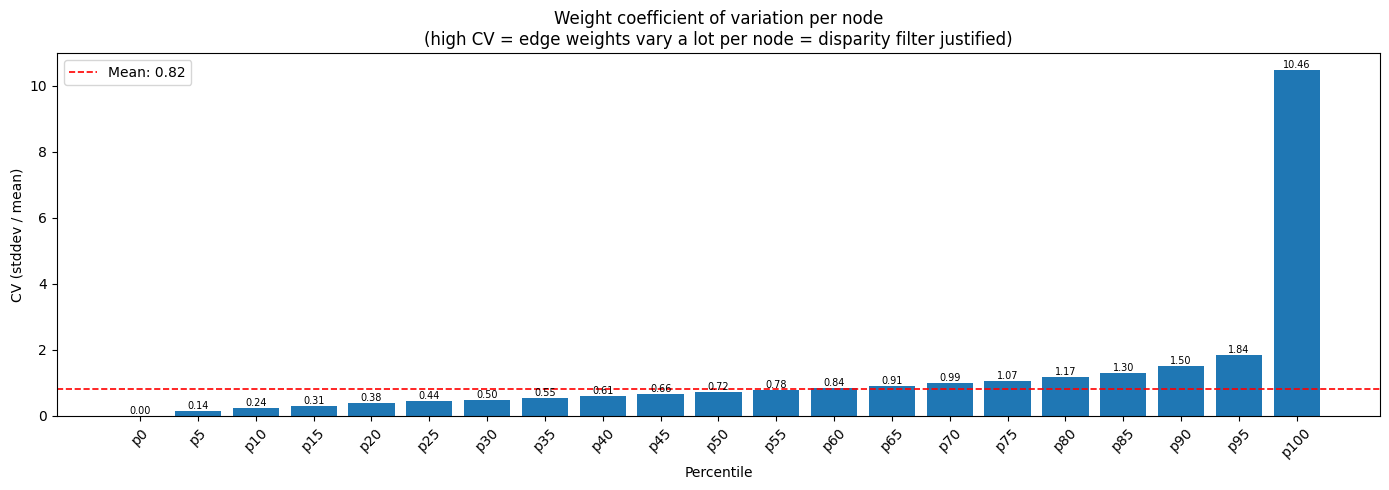

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))

percentiles = list(range(0, 101, 5))
values = np.percentile(node_stats["weight_cv"].dropna(), percentiles)
avg = node_stats["weight_cv"].mean()
p100 = node_stats["weight_cv"].max()

bars = ax.bar(
    [f"p{p}" for p in percentiles],
    values,
    edgecolor="none"
)
ax.axhline(avg, color="red", linestyle="--", linewidth=1.2, label=f"Mean: {avg:.2f}")
ax.set_title(
    f"Weight coefficient of variation per node\n"
    f"(high CV = edge weights vary a lot per node = disparity filter justified)"
)
ax.set_xlabel("Percentile")
ax.set_ylabel("CV (stddev / mean)")
ax.tick_params(axis="x", rotation=45)
ax.legend()

for i, (bar, val) in enumerate(zip(bars, values)):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{val:.2f}",
        ha="center", va="bottom", fontsize=7
    )

print(f"Max weight (p100): {p100}")
plt.tight_layout()
plt.show()

In [11]:
extreme_cv = node_stats[node_stats["weight_cv"] > 3].sort_values("weight_cv", ascending=False)

print(f"Nodes with CV > 3: {len(extreme_cv)} ({len(extreme_cv)/len(node_stats)*100:.2f}% of all nodes)")
print(extreme_cv[["subreddit_id", "degree", "strength", "avg_edge_weight", "weight_cv"]].head(20))

Nodes with CV > 3: 57 (0.40% of all nodes)
      subreddit_id  degree  strength  avg_edge_weight  weight_cv
4449      t5_2sf6m     437   32066.0        73.377574  10.464128
880       t5_3910n     811   47282.0        58.300863   9.723318
5328      t5_2xhvq     514   27368.0        53.245136   6.760401
3639      t5_2xdxr     180   16038.0        89.100000   6.213494
10790    t5_32ulkj     182   16773.0        92.159341   6.075444
6242      t5_2qktn     205   12076.0        58.907317   5.588588
10775    t5_446kys    1763   95464.0        54.148610   5.312043
882       t5_2qhds     691   28132.0        40.712012   4.865780
13068    t5_aes7p2      67    3626.0        54.119403   4.713559
7140     t5_7ikpd3      66    5095.0        77.196970   4.549226
10780    t5_4uoy2u    1573   61555.0        39.132231   4.545450
8153      t5_2rj3j      99    5344.0        53.979798   4.344081
5517     t5_7zifh8      46    8370.0       181.956522   4.319391
11790     t5_3ndbi      73    2391.0        32.

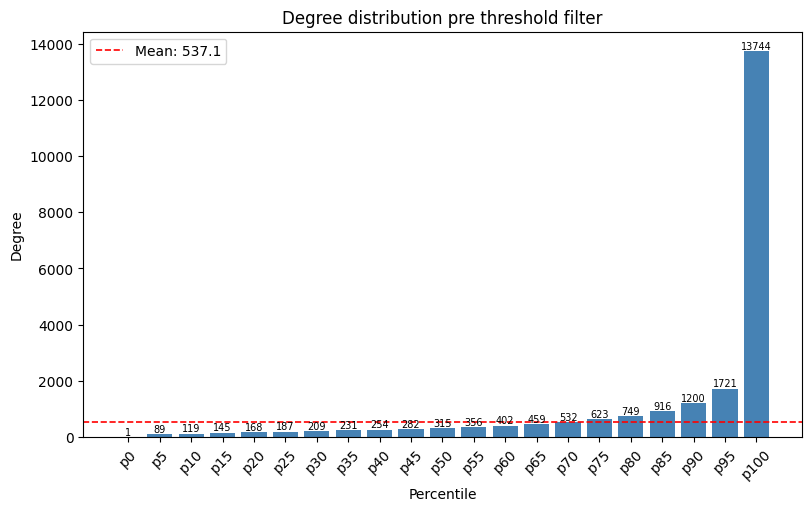

In [12]:
# Setup
percentiles = list(range(0, 101, 5))
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

# Data
raw_degree_values = raw_node_stats["degree"].values
pct_values = np.percentile(raw_degree_values, percentiles)
avg = raw_degree_values.mean()

# Plot
bars = ax.bar([f"p{p}" for p in percentiles], pct_values, color="steelblue", edgecolor="none")
ax.axhline(avg, color="red", linestyle="--", linewidth=1.2, label=f"Mean: {avg:.1f}")

# Formatting
ax.set_title("Degree distribution pre threshold filter")
ax.set_xlabel("Percentile")
ax.set_ylabel("Degree")
ax.tick_params(axis="x", rotation=45)
ax.legend()

# Labels
for bar, val in zip(bars, pct_values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), 
            f"{val:.0f}", ha="center", va="bottom", fontsize=7)

plt.savefig(fname="images/pre_threshold.png")
plt.show()

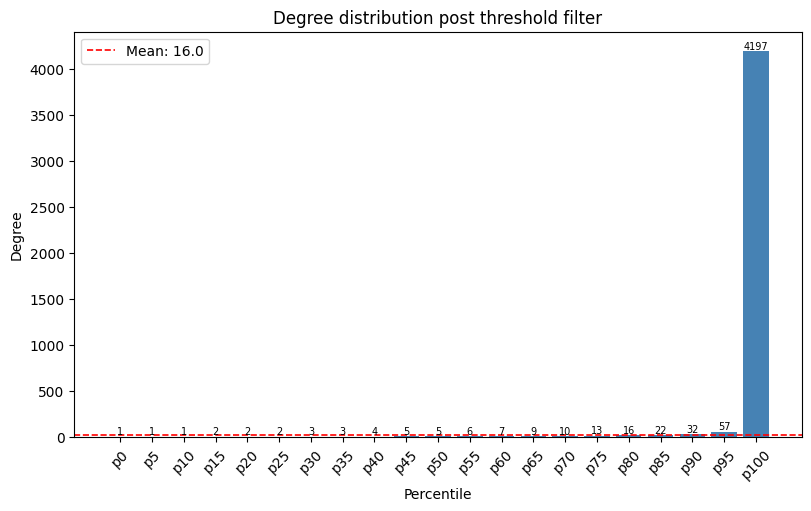

In [13]:
# Setup
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

# Data
degree_values = node_stats["degree"].values
pct_values = np.percentile(degree_values, percentiles)
avg = degree_values.mean()

# Plot
bars = ax.bar([f"p{p}" for p in percentiles], pct_values, color="steelblue", edgecolor="none")
ax.axhline(avg, color="red", linestyle="--", linewidth=1.2, label=f"Mean: {avg:.1f}")

# Formatting
ax.set_title("Degree distribution post threshold filter")
ax.set_xlabel("Percentile")
ax.set_ylabel("Degree")
ax.tick_params(axis="x", rotation=45)
ax.legend()

# Labels
for bar, val in zip(bars, pct_values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), 
            f"{val:.0f}", ha="center", va="bottom", fontsize=7)

plt.savefig(fname="images/post_threshold.png")
plt.show()

Analysis of the degree distribution reveals a power law consistent with a scale-free network [1], with a small number of high-degree hubs exhibiting highly heterogeneous weight distributions (CV up to 10.46). Following [2], we apply the disparity filter to extract the network backbone, preserving edges whose normalized weight is statistically significant under the null hypothesis of uniform strength distribution, with significance threshold α. This per-node approach is specifically suited to our network structure, as it applies strict criteria to hub nodes while preserving the meaningful connections of peripheral nodes.

In [14]:
def apply_disparity_filter(alpha):
    temp_df = con.execute(f"""
    WITH edges AS (
        SELECT subreddit_id_a AS subreddit_id, subreddit_id_b AS neighbor, shared_users
        FROM filtered_df
        UNION ALL
        SELECT subreddit_id_b, subreddit_id_a, shared_users
        FROM filtered_df
    ),
    strength AS (
        SELECT subreddit_id, SUM(shared_users) AS total_strength, COUNT(*) AS degree
        FROM edges
        GROUP BY 1
    ),
    scored AS (
        SELECT
            e.subreddit_id,
            e.neighbor,
            e.shared_users / s.total_strength AS weight_fraction,
            e.shared_users,
            s.degree,
            POWER(1 - e.shared_users / s.total_strength, s.degree - 1) AS p_value
        FROM edges e
        JOIN strength s ON e.subreddit_id = s.subreddit_id
    )
    SELECT DISTINCT
        CASE WHEN subreddit_id < neighbor THEN subreddit_id ELSE neighbor END AS subreddit_id_a,
        CASE WHEN subreddit_id < neighbor THEN neighbor ELSE subreddit_id END AS subreddit_id_b,
        shared_users
    FROM scored
    WHERE p_value < {alpha}
    """).df()

    temp_df = temp_df.merge(
        filtered_df[["subreddit_id_a", "subreddit_id_b", "jaccard", "cosine"]],
        on=["subreddit_id_a", "subreddit_id_b"],
        how="left"
    )

    print(f"Before disparity filter: {len(filtered_df):_} edges, {len(set(filtered_df['subreddit_id_a']) | set(filtered_df['subreddit_id_b'])):_} nodes")
    print(f"After disparity filter(alpha={alpha}):  {len(temp_df):_} edges, {len(set(temp_df['subreddit_id_a']) | set(temp_df['subreddit_id_b'])):_} nodes")
    print(f"Edges retained: {len(temp_df)/len(filtered_df)*100:.1f}%")

    return temp_df

In [15]:
def df_to_graph(df):
    G = nx.from_pandas_edgelist(
        df, 
        source='subreddit_id_a', 
        target='subreddit_id_b', 
        edge_attr='shared_users'
    )
    return G

In [16]:
alphas = [0.001, 0.005, 0.01, 0.02, 0.05, 0.075, 0.1, 0.15, 0.2]

dfs_dict = {}

for a in alphas:
    dfs_dict[a] = apply_disparity_filter(a)

Before disparity filter: 114_922 edges, 14_354 nodes
After disparity filter(alpha=0.001):  1_746 edges, 1_789 nodes
Edges retained: 1.5%
Before disparity filter: 114_922 edges, 14_354 nodes
After disparity filter(alpha=0.005):  2_788 edges, 2_588 nodes
Edges retained: 2.4%
Before disparity filter: 114_922 edges, 14_354 nodes
After disparity filter(alpha=0.01):  3_507 edges, 3_124 nodes
Edges retained: 3.1%
Before disparity filter: 114_922 edges, 14_354 nodes
After disparity filter(alpha=0.02):  4_629 edges, 3_865 nodes
Edges retained: 4.0%
Before disparity filter: 114_922 edges, 14_354 nodes
After disparity filter(alpha=0.05):  7_175 edges, 5_346 nodes
Edges retained: 6.2%
Before disparity filter: 114_922 edges, 14_354 nodes
After disparity filter(alpha=0.075):  9_038 edges, 6_187 nodes
Edges retained: 7.9%
Before disparity filter: 114_922 edges, 14_354 nodes
After disparity filter(alpha=0.1):  10_883 edges, 6_944 nodes
Edges retained: 9.5%
Before disparity filter: 114_922 edges, 14_35

In [17]:
results = {}

for alpha, df in dfs_dict.items():
    G = df_to_graph(df)
    
    largest_cc = max(nx.connected_components(G), key=len)
    giant_comp_ratio = len(largest_cc) / len(G.nodes)
    
    communities = nx.community.louvain_communities(G, weight='shared_users')
    modularity = nx.community.modularity(G, communities, weight='shared_users')
    
    results[alpha] = {
        "Giant Component %": giant_comp_ratio,
        "Modularity": modularity
    }

In [18]:
for a in alphas:
    print(f"{a}: {results[a]}")

0.001: {'Giant Component %': 0.3465623253214086, 'Modularity': 0.9062468833069799}
0.005: {'Giant Component %': 0.4632921174652241, 'Modularity': 0.9018760891187673}
0.01: {'Giant Component %': 0.46959026888604355, 'Modularity': 0.8976393213550665}
0.02: {'Giant Component %': 0.5003880983182406, 'Modularity': 0.8936295203999398}
0.05: {'Giant Component %': 0.6234567901234568, 'Modularity': 0.8813322379960977}
0.075: {'Giant Component %': 0.6754485210926136, 'Modularity': 0.8759868643513666}
0.1: {'Giant Component %': 0.709389400921659, 'Modularity': 0.8668461060164444}
0.15: {'Giant Component %': 0.7462378640776699, 'Modularity': 0.8557498931036164}
0.2: {'Giant Component %': 0.7890026954177898, 'Modularity': 0.849319183011034}


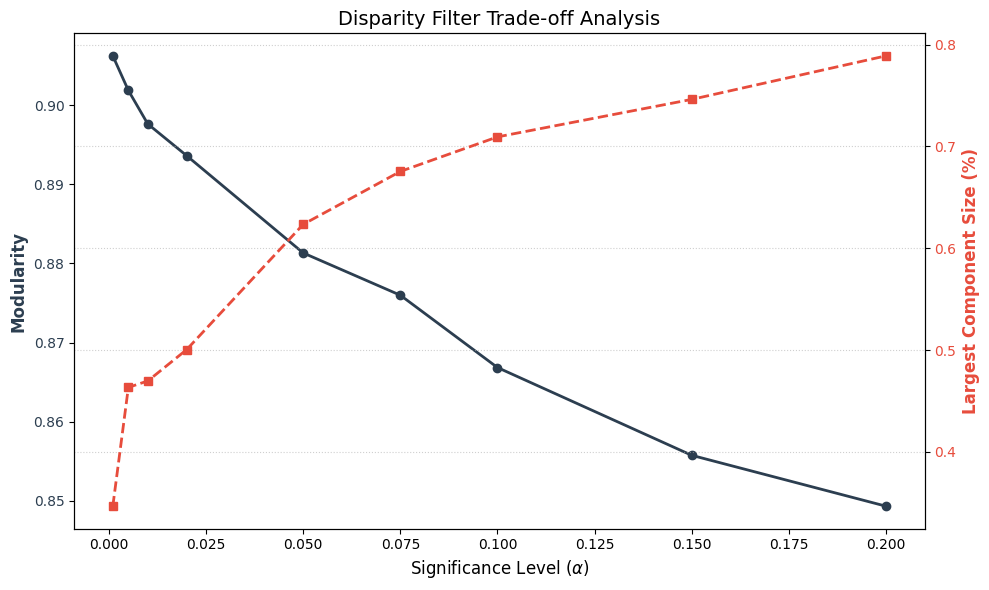

In [20]:
modularity_vals = [results[a]['Modularity'] for a in alphas]
gc_vals = [results[a]['Giant Component %'] for a in alphas]

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Modularity (Left Y-axis)
color1 = '#2c3e50' # Dark Blue/Grey
ax1.set_xlabel(r'Significance Level ($\alpha$)', fontsize=12)
ax1.set_ylabel('Modularity', color=color1, fontsize=12, fontweight='bold')
ax1.plot(alphas, modularity_vals, marker='o', color=color1, linewidth=2, label='Modularity')
ax1.tick_params(axis='y', labelcolor=color1)

# Plot Giant Component (Right Y-axis)
ax2 = ax1.twinx()
color2 = '#e74c3c' # Red
ax2.set_ylabel('Largest Component Size (%)', color=color2, fontsize=12, fontweight='bold')
ax2.plot(alphas, gc_vals, marker='s', color=color2, linewidth=2, linestyle='--', label='Giant Component')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Disparity Filter Trade-off Analysis', fontsize=14)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.savefig(fname="images/disparity_filter.png")
plt.show()

## References

[1] Barabási, A.L. and Albert, R. (1999). Emergence of scaling in random networks. Science, 286(5439), 509–512. https://doi.org/10.1126/science.286.5439.509

[2] Serrano, M.Á., Boguñá, M., and Vespignani, A. (2009). Extracting the multiscale backbone of complex weighted networks. Proceedings of the National Academy of Sciences, 106(16), 6483–6488. https://doi.org/10.1073/pnas.0808904106